In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     BatchNormalization, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d belalsafy/egyptian-new-currency-2023

Dataset URL: https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023
License(s): unknown
100% 395M/395M [00:03<00:00, 107MB/s]



In [ ]:
!unzip egyptian-new-currency-2023.zip

Archive:  egyptian-new-currency-2023.zip
  inflating: dataset/test/1/1.100.jpg  
  inflating: dataset/test/1/1.22.jpg  
  inflating: dataset/test/1/1.24.jpg  
  inflating: dataset/test/1/1.26.jpg  
  inflating: dataset/test/1/1.28.jpg  
  inflating: dataset/test/1/1.40.jpg  
  inflating: dataset/test/1/1.41.jpg  
  inflating: dataset/test/1/1.42.jpg  
  inflating: dataset/test/1/1.5.jpg  
  inflating: dataset/test/1/1.56.jpg  
  inflating: dataset/test/1/1.59.jpg  
  inflating: dataset/test/1/1.6.jpg  
  inflating: dataset/test/1/1.65.jpg  
  inflating: dataset/test/1/1.7.jpg  
  inflating: dataset/test/1/1.70.jpg  
  inflating: dataset/test/1/1.74.jpg  
  inflating: dataset/test/1/1.78.jpg  
  inflating: dataset/test/1/1.79.jpg  
  inflating: dataset/test/1/1.84.jpg  
  inflating: dataset/test/1/1.97.jpg  
  inflating: dataset/test/10 (new)/210.jpg  
  inflating: dataset/test/10 (new)/310.jpg  
  inflating: dataset/test/10 (new)/4110.jpg  
  inflating: dataset/test/10 (new)/510.jpg  


In [ ]:
import zipfile
import os

# فك الضغط
with zipfile.ZipFile('egyptian-new-currency-2023.zip', 'r') as z:
    z.extractall('dataset')

# شوف الفولدرات
for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for file in files[:3]:  # أول 3 فايلات بس
            print(f'{indent}  {file}')

dataset/
  dataset/
    test/
      20 (new)/
      50/
      5/
      10/
      100/
      10 (new)/
      200/
      1/
      20/
    train/
      20 (new)/
      50/
      5/
      10/
      100/
      10 (new)/
      200/
      1/
      20/
    valid/
      20 (new)/
      50/
      5/
      10/
      100/
      10 (new)/
      200/
      1/
      20/
  test/
    20 (new)/
      IMG_20231216_065102 - Copy.jpg
      IMG-20231215-WA0014.jpg
      IMG_20231216_070135 - Copy.jpg
    50/
      IMG-20231217-WA0463.jpg
      50.1.jpg
      IMG-20231217-WA0523.jpg
    5/
      IMG_20231217_032108.jpg
      5.9.jpg
      IMG-20231217-WA0558.jpg
    10/
      10.10.jpg
      IMG-20231217-WA0403.jpg
      10.64.jpg
    100/
      IMG-20231217-WA0268.jpg
      IMG-20231217-WA0310.jpg
      100.36.jpg
    10 (new)/
      IMG-20231216-WA0040.jpg
      57e2dd434855a414f1dc8460962e33791c3ad6e04e507440742a7ed09f44c3_640.jpg
      IMG-20231216-WA0044.jpg
    200/
      200.10.jpg
      200.29.jpg
  

In [ ]:
import os
from pathlib import Path

dataset_path = Path('dataset')

for split in ['train', 'valid', 'test']:
    print(f"\n📁 {split.upper()}:")
    split_path = dataset_path / split
    total = 0
    for class_folder in sorted(split_path.iterdir()):
        if class_folder.is_dir():
            count = len(list(class_folder.glob('*.jpg')))
            total += count
            print(f"   {class_folder.name:<12} → {count} صورة")
    print(f"   {'TOTAL':<12} → {total} صورة")


📁 TRAIN:
   1            → 60 صورة
   10           → 313 صورة
   10 (new)     → 317 صورة
   100          → 315 صورة
   20           → 322 صورة
   20 (new)     → 346 صورة
   200          → 311 صورة
   5            → 334 صورة
   50           → 315 صورة
   TOTAL        → 2633 صورة

📁 VALID:
   1            → 20 صورة
   10           → 79 صورة
   10 (new)     → 130 صورة
   100          → 80 صورة
   20           → 80 صورة
   20 (new)     → 130 صورة
   200          → 78 صورة
   5            → 80 صورة
   50           → 80 صورة
   TOTAL        → 757 صورة

📁 TEST:
   1            → 20 صورة
   10           → 33 صورة
   10 (new)     → 30 صورة
   100          → 35 صورة
   20           → 35 صورة
   20 (new)     → 30 صورة
   200          → 35 صورة
   5            → 35 صورة
   50           → 35 صورة
   TOTAL        → 288 صورة


In [ ]:
!pip install torch torchvision timm scikit-learn matplotlib seaborn -q

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using: {device}")

✅ Using: cuda


In [ ]:
import os
import json
from pathlib import Path
from PIL import Image

dataset_path = Path('dataset')

# Mapping اسم الفولدر → class index
class_names = sorted([
    d.name for d in (dataset_path/'train').iterdir() if d.is_dir()
])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("Classes:")
for k, v in class_to_idx.items():
    print(f"  {v}: {k}")

# حفظ الـ class names
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

Classes:
  0: 1
  1: 10
  2: 10 (new)
  3: 100
  4: 20
  5: 20 (new)
  6: 200
  7: 5
  8: 50


In [ ]:
def create_yolo_label(image_path, class_idx, output_label_path, margin=0.05):
    """
    bbox = الصورة كلها مع margin صغير
    margin=0.05 يعني 5% من الحواف فاضية
    """
    img = Image.open(image_path)
    w, h = img.size

    # YOLO format: x_center y_center width height (كلها نسب من 0 لـ 1)
    x_center = 0.5
    y_center = 0.5
    bbox_w   = 1.0 - (2 * margin)
    bbox_h   = 1.0 - (2 * margin)

    label_line = f"{class_idx} {x_center} {y_center} {bbox_w:.4f} {bbox_h:.4f}\n"

    os.makedirs(output_label_path.parent, exist_ok=True)
    with open(output_label_path, 'w') as f:
        f.write(label_line)

# إنشاء الـ labels لكل split
total = 0
for split in ['train', 'valid', 'test']:
    split_path = dataset_path / split
    for class_folder in split_path.iterdir():
        if not class_folder.is_dir():
            continue
        class_idx = class_to_idx[class_folder.name]
        for img_file in class_folder.glob('*.jpg'):
            label_path = Path('labels') / split / class_folder.name / (img_file.stem + '.txt')
            create_yolo_label(img_file, class_idx, label_path)
            total += 1

print(f"✅ تم إنشاء {total} label file")

✅ تم إنشاء 3678 label file


In [ ]:
import shutil

yolo_path = Path('yolo_dataset')

for split in ['train', 'valid', 'test']:
    # إنشاء فولدرات images و labels
    (yolo_path / 'images' / split).mkdir(parents=True, exist_ok=True)
    (yolo_path / 'labels' / split).mkdir(parents=True, exist_ok=True)

    split_path = dataset_path / split
    for class_folder in split_path.iterdir():
        if not class_folder.is_dir():
            continue
        class_idx = class_to_idx[class_folder.name]

        for img_file in class_folder.glob('*.jpg'):
            # Copy image
            shutil.copy(img_file, yolo_path / 'images' / split / img_file.name)

            # Copy label
            src_label = Path('labels') / split / class_folder.name / (img_file.stem + '.txt')
            dst_label = yolo_path / 'labels' / split / (img_file.stem + '.txt')
            shutil.copy(src_label, dst_label)

print("✅ YOLO dataset structure ready!")

✅ YOLO dataset structure ready!


In [ ]:
yaml_content = f"""path: /content/yolo_dataset
train: images/train
val: images/valid
test: images/test

nc: {len(class_names)}
names: {class_names}
"""

with open('banknotes.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ banknotes.yaml created!")
print(yaml_content)

✅ banknotes.yaml created!
path: /content/yolo_dataset
train: images/train
val: images/valid
test: images/test

nc: 9
names: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']



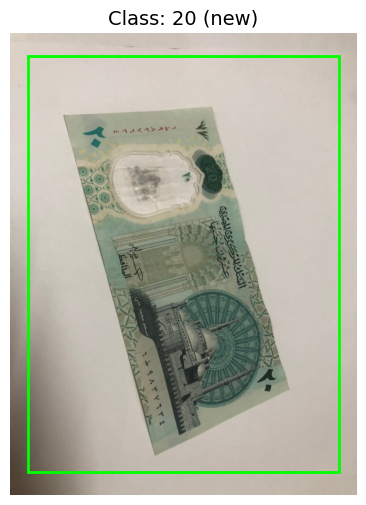

✅ Image: photo_54_2023-12-16_04-05-38.jpg | Label: 20 (new)


In [ ]:
# اتأكد من صورة عشوائية وlabelها
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

split = 'train'
all_imgs = list((yolo_path / 'images' / split).glob('*.jpg'))
sample = random.choice(all_imgs)

img = Image.open(sample)
w, h = img.size

label_file = yolo_path / 'labels' / split / (sample.stem + '.txt')
with open(label_file) as f:
    line = f.read().strip().split()

cls_idx = int(line[0])
xc, yc, bw, bh = map(float, line[1:])

# Convert to pixel coords
x1 = (xc - bw/2) * w
y1 = (yc - bh/2) * h
box_w = bw * w
box_h = bh * h

fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(img)
rect = patches.Rectangle((x1, y1), box_w, box_h,
                           linewidth=2, edgecolor='lime', facecolor='none')
ax.add_patch(rect)
ax.set_title(f"Class: {class_names[cls_idx]}", fontsize=14)
plt.axis('off')
plt.show()
print(f"✅ Image: {sample.name} | Label: {class_names[cls_idx]}")

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch

print(f"✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU - اتأكد إنك فاتح GPU في Colab'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU: Tesla T4


In [ ]:
model = YOLO('yolov8m.pt')  # medium = توازن بين سرعة ودقة

results = model.train(
    data='/content/banknotes.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='egyptian_banknotes',
    patience=10,          # early stopping
    save=True,
    plots=True,
    verbose=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/banknotes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=egyptian_banknotes, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [ ]:
model = YOLO('/content/runs/detect/egyptian_banknotes/weights/best.pt')

metrics = model.val(
    data='/content/banknotes.yaml',
    split='test'
)

print(f"\n📊 النتائج:")
print(f"   mAP50:    {metrics.box.map50:.4f}")
print(f"   mAP50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,844,971 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.6±16.6 MB/s, size: 139.5 KB)
val: Scanning /content/yolo_dataset/labels/test... 288 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 288/288 192.6it/s 1.5s
val: /content/yolo_dataset/images/test/20.3.jpg: corrupt JPEG restored and saved
val: /content/yolo_dataset/images/test/50.1.jpg: corrupt JPEG restored and saved
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.2it/s 8.0s
                   all        288        288      0.989      0.985      0.995      0.994
                     1         20         20       0.98          1      0.995      0.995
                    10         33         33          1      0.992      0.995      0.992
   


image 1/1 /content/yolo_dataset/images/test/32 - Copy.jpg: 640x352 1 20 (new), 83.2ms
Speed: 6.4ms preprocess, 83.2ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 352)


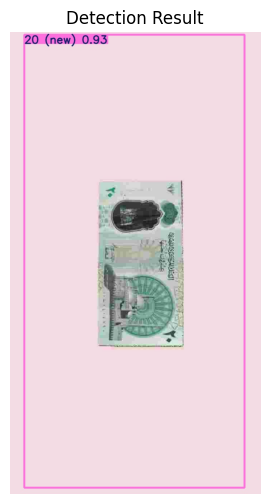

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

# صورة عشوائية من التيست
test_imgs = list(Path('/content/yolo_dataset/images/test').glob('*.jpg'))
sample = random.choice(test_imgs)

results = model(sample, conf=0.25)
results[0].save(filename='prediction.jpg')

plt.figure(figsize=(8, 6))
plt.imshow(Image.open('prediction.jpg'))
plt.axis('off')
plt.title('Detection Result')
plt.show()

In [ ]:
import shutil, json

# الموديل
shutil.copy(
    '/content/runs/detect/egyptian_banknotes/weights/best.pt',
    '/content/best.pt'
)

# الـ class names
import yaml
with open('/content/banknotes.yaml') as f:
    data = yaml.safe_load(f)

with open('/content/class_names.json', 'w') as f:
    json.dump(data['names'], f)

# Download للجهاز
from google.colab import files
files.download('/content/best.pt')
files.download('/content/class_names.json')

print("✅ الموديل جاهز للـ API!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ الموديل جاهز للـ API!


In [ ]:
from google.colab import files

files.download('/content/runs/detect/egyptian_banknotes/weights/best.pt')
files.download('/content/class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>